# 03 — Spatial LCA, TEA, and societal life-cycle cost (sLCC)

Clean spatial workflow built on the **same deterministic TEA/LCA core** used by notebooks 01–02.

**Location-dependent inputs only:** state electricity/feedstock prices and regional electricity/diesel/natural-gas emission factors. The three environmental-factor tables are project-owned regenerated inputs; only the state-to-region source mapping remains external by default.

**sLCC policy retained from the legacy workflow:** 3% central social discount rate, SPC=1.10, financing/income tax/IDC excluded from social resource cost, and environmental damage schedules applied to annual production.

Set `RUN_FULL_SPATIAL=False` for the first preflight. After every gate passes, the regenerated EF tables are present, and the external state-source map is found, set it to `True`.

In [19]:
from pathlib import Path
import json, os, sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Locate project root BEFORE importing graphite_sus
# ---------------------------------------------------------------------
HERE = Path.cwd().resolve()

_candidates = [
    HERE,
    HERE.parent,
    HERE.parent.parent,
    HERE.parent.parent.parent,
]

PROJECT_ROOT = next(
    (
        p for p in _candidates
        if (p / "graphite_sus").is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise RuntimeError(
        "Could not locate project root containing graphite_sus/.\n"
        f"Current working directory: {HERE}\n"
        f"Checked: {[str(p) for p in _candidates]}"
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Current directory:", HERE)
print("Project root:", PROJECT_ROOT)


# ---------------------------------------------------------------------
# NOW import project modules
# ---------------------------------------------------------------------
from graphite_sus.spatial.config import (
    SpatialPaths,
    DEFAULT_SPATIAL_METHODS,
    CANON_IMPACTS,
)

from graphite_sus.spatial.prices import (
    load_state_electricity_prices,
    load_state_feedstock_prices,
    build_state_price_table,
)

from graphite_sus.spatial.damage_costs import DamageCostLibrary
from graphite_sus.market_reference import load_market_references


# ---------------------------------------------------------------------
# Project settings
# ---------------------------------------------------------------------
PROJECT_NAME = "graphite_sys_v3"

LCI_WORKBOOK = (
    PROJECT_ROOT
    / "graphite_sus"
    / "data"
    / "test"
    / "meb_bw_char_coke_v96.xlsx"
)

TEA_WORKBOOK = (
    PROJECT_ROOT
    / "graphite_sus"
    / "data"
    / "test"
    / "meb_tea_char_coke_v53.xlsx"
)

OUTPUT_DIR = PROJECT_ROOT / "result" / "spatial"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SCENARIOS = ("s_c1", "s_c2", "s_o1", "s_o2")
TEA_PROFILE = "literature_hybrid"

ELECTRICITY_SNAPSHOT = "2025-03-01"
ELECTRICITY_PRICE_MODE = "snapshot"

SOCIAL_RATE = 0.03     # 0.01, 0.03, 0.05
SPC = 1.1              # 1.05, 1.1, 1.2
DAMAGE_SCENARIO = "central" # low, central, high

RUN_FULL_SPATIAL = True
RUN_SLCC_SENSITIVITY = True
RUN_MAPS = True

PATHS = SpatialPaths()
METHODS = DEFAULT_SPATIAL_METHODS

print("LCI workbook:", LCI_WORKBOOK)
print("TEA workbook:", TEA_WORKBOOK)
print("Output dir:", OUTPUT_DIR)
print("RUN_FULL_SPATIAL =", RUN_FULL_SPATIAL)
print("RUN_SLCC_SENSITIVITY =", RUN_SLCC_SENSITIVITY)
print("RUN_MAPS =", RUN_MAPS)

assert TEA_WORKBOOK.exists(), TEA_WORKBOOK


Current directory: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/notebooks
Project root: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2
LCI workbook: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/graphite_sus/data/test/meb_bw_char_coke_v96.xlsx
TEA workbook: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/graphite_sus/data/test/meb_tea_char_coke_v53.xlsx
Output dir: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/spatial
RUN_FULL_SPATIAL = True
RUN_SLCC_SENSITIVITY = True
RUN_MAPS = True


## 1. Spatial input audit

In [20]:
input_audit = PATHS.audit()
display(input_audit)

# Static package inputs must always exist. The state-source mapping can remain
# external. Regenerated electricity/diesel/natural-gas EF tables are mandatory
# for full spatial LCA but can be absent during lightweight preflight.
internal = {"electricity_prices","feedstock_prices","market_impacts","state_geometries","damage_reference","damage_overrides","cpi_reference"}
assert input_audit.loc[input_audit.input.isin(internal), 'exists'].all()
regional_ok = input_audit.loc[~input_audit.input.isin(internal), 'exists'].all()
print('State-source map + regenerated regional EF files available:', bool(regional_ok))
if not bool(input_audit.loc[input_audit.input.eq('electricity_ef'), 'exists'].all()):
    print('Regenerate electricity first: python scripts/regenerate_electricity_factors.py all')


,input,path,exists
0,electricity_prices,/mnt/g/My Drive/yale/Project-graphite/graphite...,True
1,feedstock_prices,/mnt/g/My Drive/yale/Project-graphite/graphite...,True
2,market_impacts,/mnt/g/My Drive/yale/Project-graphite/graphite...,True
3,state_geometries,/mnt/g/My Drive/yale/Project-graphite/graphite...,True
4,damage_reference,/mnt/g/My Drive/yale/Project-graphite/graphite...,True
5,damage_overrides,/mnt/g/My Drive/yale/Project-graphite/graphite...,True
6,cpi_reference,/mnt/g/My Drive/yale/Project-graphite/graphite...,True
7,state_source_map,/mnt/g/My Drive/ElectricityLCI_derived_data/en...,True
8,electricity_ef,/mnt/g/My Drive/yale/Project-graphite/graphite...,True
9,diesel_ef,/mnt/g/My Drive/yale/Project-graphite/graphite...,True


State-source map + regenerated regional EF files available: True


## 2. State prices — explicit 2025 snapshot vs legacy averaging

In [21]:
ele = load_state_electricity_prices(PATHS.electricity_prices, snapshot=ELECTRICITY_SNAPSHOT, mode=ELECTRICITY_PRICE_MODE)
feed = load_state_feedstock_prices(PATHS.feedstock_prices)
state_prices = build_state_price_table(ele, feed)
display(state_prices.describe(include='all'))
display(state_prices.head())

# Audit the historical behavior. The legacy notebook averaged every numeric price
# column, which currently mixes March-2024 and March-2025. This table makes the
# numerical consequence explicit rather than silently reproducing it.
ele_legacy = load_state_electricity_prices(PATHS.electricity_prices, snapshot=ELECTRICITY_SNAPSHOT, mode='legacy_mean')
elec_audit = ele[['state','value']].merge(ele_legacy[['state','value']], on='state', suffixes=('_snapshot','_legacy_mean'))
elec_audit['delta_usd_per_kwh'] = elec_audit.value_snapshot - elec_audit.value_legacy_mean
display(elec_audit.sort_values('delta_usd_per_kwh', key=lambda s:s.abs(), ascending=False).head(10))
assert state_prices.state.nunique() >= 48

,state,electricity_usd_per_kwh,feedstock_usd_per_kg
count,51,51.000000,51.000000
unique,51,NaN,NaN
top,AK,NaN,NaN
freq,1,NaN,NaN
mean,NaN,0.101998,0.055055
std,NaN,0.053706,0.011256
min,NaN,0.052500,0.023319
25%,NaN,0.073650,0.051421
50%,NaN,0.079600,0.058994
75%,NaN,0.100600,0.063777


,state,electricity_usd_per_kwh,feedstock_usd_per_kg
0,AK,0.2016,0.030294
1,AL,0.0744,0.066169
2,AR,0.0628,0.064973
3,AZ,0.0784,0.059991
4,CA,0.1984,0.062781


,state,value_snapshot,value_legacy_mean,delta_usd_per_kwh
4,RI,0.2496,0.21215,0.03745
50,HI,0.3177,0.33815,-0.02045
25,MD,0.1333,0.11320,0.02010
22,DC,0.1336,0.11485,0.01875
0,CT,0.1982,0.17995,0.01825
1,ME,0.1632,0.14550,0.01770
9,IL,0.1063,0.09505,0.01125
44,UT,0.0791,0.07205,0.00705
6,NJ,0.1305,0.12390,0.00660
49,AK,0.2016,0.20765,-0.00605


## 3. Damage-cost reference and annual schedules

**Edit damage costs without editing Python:**

- source ranges / base dollar year / growth rule → `graphite_sus/data/spatial/damage_cost_reference.csv`
- any individual annual value → `graphite_sus/data/spatial/damage_cost_schedule_overrides.csv`

Override rows use `impact_category, scenario, operation_year, value, target_dollar_year, lcia_unit`. A scenario of `all` applies the value to low/central/high.

In [22]:
damage_lib = DamageCostLibrary(
    PATHS.damage_reference, PATHS.cpi_reference, PATHS.damage_overrides, target_dollar_year=2025
)
damage_reference = damage_lib.rebased_reference()
damage_schedules = damage_lib.schedules(years_ops=30)
damage_schedule_table = damage_lib.schedule_table(years_ops=30)
display(damage_reference)
display(damage_schedule_table.query("scenario == 'central'").head(12))
damage_schedule_table.to_csv(OUTPUT_DIR / 'damage_cost_schedule_used.csv', index=False)

# Required ordering for every project year.
for cat in CANON_IMPACTS:
    lo = damage_schedules[cat]['low']; cen = damage_schedules[cat]['central']; hi = damage_schedules[cat]['high']
    assert np.all(lo <= cen) and np.all(cen <= hi)

,impact_category,low,high,reference_dollar_year,lcia_unit,schedule_mode,annual_real_growth,source,ref,note,inflation_factor,low_target,high_target,central_target,target_dollar_year
0,climate change,0.114000,0.311000,2019,USD/kg CO2-eq,geometric,0.015,legacy spatial sLCC implementation,NaN,Equivalent to 114-311 USD/t CO2 before CPI reb...,1.259272,0.143557,0.391634,0.267595,2025
1,acidification,0.239000,0.584000,2019,USD/kg SO2-eq,constant,0.000,legacy spatial sLCC implementation,NaN,NaN,1.259272,0.300966,0.735415,0.518190,2025
2,eutrophication,20.090000,29.836000,2019,USD/kg N-eq,constant,0.000,legacy spatial sLCC implementation,NaN,NaN,1.259272,25.298778,37.571644,31.435211,2025
3,ecotoxicity: freshwater,0.001839,0.007886,2019,USD/CTUe,constant,0.000,legacy spatial sLCC implementation,NaN,Converted in legacy code from 1.582-6.785 USD/...,1.259272,0.002316,0.009931,0.006123,2025
4,particulate matter formation,550.000000,664.000000,2019,USD/kg PM2.5-eq,constant,0.000,legacy spatial sLCC implementation,NaN,IMPORTANT provenance check: active notebook ra...,1.259272,692.599684,836.156709,764.378197,2025
5,photochemical oxidant formation,0.006000,0.483000,2019,USD/kg O3-eq,constant,0.000,legacy spatial sLCC implementation,NaN,Converted in legacy code from 0.006-0.483 USD/...,1.259272,0.007556,0.608228,0.307892,2025


,impact_category,scenario,operation_year,value,target_dollar_year,lcia_unit
30,climate change,central,1,0.267595,2025,USD/kg CO2-eq
31,climate change,central,2,0.271609,2025,USD/kg CO2-eq
32,climate change,central,3,0.275683,2025,USD/kg CO2-eq
33,climate change,central,4,0.279819,2025,USD/kg CO2-eq
34,climate change,central,5,0.284016,2025,USD/kg CO2-eq
35,climate change,central,6,0.288276,2025,USD/kg CO2-eq
36,climate change,central,7,0.292600,2025,USD/kg CO2-eq
37,climate change,central,8,0.296989,2025,USD/kg CO2-eq
38,climate change,central,9,0.301444,2025,USD/kg CO2-eq
39,climate change,central,10,0.305966,2025,USD/kg CO2-eq


## 4. Current centralized market graphite references

In [23]:
market_refs = load_market_references()
display(market_refs)

,market_type,quantity,lo,hi,mean,unit,geography,source,ref,note
0,natural,MSP,2.8,4.5,3.65,USD/kg,U.S.,project_selected_market_range,NaN,Authoritative project market-natural-graphite ...
1,synthetic,MSP,4.2,5.3,4.75,USD/kg,U.S.,project_selected_market_range,NaN,Authoritative project market-synthetic-graphit...


## 5. Brightway project and shared deterministic scenario bundles

In [24]:
import bw2data as bd
from graphite_sus.workflow import prepare_scenario, deterministic_streams, run_deterministic_tea
from graphite_sus.spatial.tea import SpatialTEARunner
from graphite_sus.fuel_reference import (
    audit_system_fuel_reference,
    audit_spatial_ef_ranges,
    fuel_reference_manifest,
)

bd.projects.set_current(PROJECT_NAME)


# Verify that the central Brightway system still contains the regenerated
# EPA/NETL representative diesel and natural-gas factors.  Spatial Section 8
# separately verifies that the external regional envelopes match this same
# central reference.
fuel_ef_audit = audit_system_fuel_reference("graphite_system")
assert not fuel_ef_audit.empty, (
    "No fuel UF parameters were found in graphite_system. "
    "Run notebook 01 first so the regenerated NETL fuel reference is applied."
)
fuel_ef_audit.to_csv(OUTPUT_DIR / "fuel_ef_reference_audit.csv", index=False)
display(fuel_ef_audit)
assert bool(fuel_ef_audit["passed"].all()), (
    "The Brightway graphite_system fuel UFs do not match "
    "data/fuel_ef_netl_reference.csv. Rerun notebook 01 after regenerating "
    "the diesel/natural-gas factors."
)

bundles = {
    sc: prepare_scenario(sc, workbook_path=TEA_WORKBOOK, electricity_mode='national_2025')
    for sc in SCENARIOS
}
streams_by_scenario = {sc: deterministic_streams(b)[0] for sc,b in bundles.items()}
tea_runner = SpatialTEARunner(bundles, tea_profile=TEA_PROFILE)

,activity,variable,actual,expected,passed
0,"graphite production, from coke, no byproduct (...",UF_IPCC_2021__climate_change__global_warming_p...,0.709453,0.709453,True
1,"graphite production, from coke, no byproduct (...",UF_TRACI_v2_1__acidification__acidification_po...,0.005252,0.005252,True
2,"graphite production, from coke, no byproduct (...",UF_TRACI_v2_1__eutrophication__eutrophication_...,0.000328,0.000328,True
3,"graphite production, from coke, no byproduct (...",UF_TRACI_v2_1__ecotoxicity_freshwater__ecotoxi...,1.401552,1.401552,True
4,"graphite production, from coke, no byproduct (...",UF_TRACI_v2_1__particulate_matter_formation__p...,0.000101,0.000101,True
5,"graphite production, from coke, no byproduct (...",UF_TRACI_v2_1__photochemical_oxidant_formation...,0.182250,0.182250,True
6,"graphite production, from coke, no byproduct (...",UF_IPCC_2021__climate_change__global_warming_p...,0.785507,0.785507,True
7,"graphite production, from coke, no byproduct (...",UF_TRACI_v2_1__acidification__acidification_po...,0.000866,0.000866,True
8,"graphite production, from coke, no byproduct (...",UF_TRACI_v2_1__eutrophication__eutrophication_...,0.000055,0.000055,True
9,"graphite production, from coke, no byproduct (...",UF_TRACI_v2_1__ecotoxicity_freshwater__ecotoxi...,0.356956,0.356956,True


{'CF_IPCC_2021__climate_change__global_warming_potential_GWP100__Carbon_dioxide_fossil__air__urban_air_close_to_ground': {'database': 'graphite_system', 'code': 'system::graphite_prod_char::graphtz_char', 'amount': 1.0}, 'CF_IPCC_2021__climate_change__global_warming_potential_GWP100__Dinitrogen_monoxide__air__non_urban_air_or_from_high_stacks': {'database': 'graphite_system', 'code': 'system::graphite_prod_char::graphtz_char', 'amount': 273.0}, 'CF_IPCC_2021__climate_change__global_warming_potential_GWP100__Dinitrogen_monoxide__air__urban_air_close_to_ground': {'database': 'graphite_system', 'code': 'system::graphite_prod_char::graphtz_char', 'amount': 273.0}, 'CF_IPCC_2021__climate_change__global_warming_potential_GWP100__Methane_fossil__air__urban_air_close_to_ground': {'database': 'graphite_system', 'code': 'system::graphite_prod_char::graphtz_char', 'amount': 29.8}, 'CF_IPCC_2021__climate_change__global_warming_potential_GWP100__Nitrogen_oxides__air__non_urban_air_or_from_high_stac

## 6. Hard TEA reconciliation gate

The spatial TEA runner must reproduce notebook 01 exactly when supplied the same national baseline electricity and feedstock prices. This proves that spatialization changes only state prices, not the financial model.

In [25]:
recon=[]
for sc,b in bundles.items():
    det,_,_ = run_deterministic_tea(b, tea_profile=TEA_PROFILE)
    base = tea_runner.baseline_prices(sc)
    spa,_ = tea_runner.run(sc, electricity_usd_per_kwh=base['electricity'], feedstock_usd_per_kg=base['feedstock'])
    a=float(det.summary['msp_usd_per_kg']); z=float(spa.summary['msp_usd_per_kg'])
    recon.append({'scenario':sc,'deterministic_msp':a,'spatial_runner_at_same_prices':z,'abs_delta':abs(a-z),'pass':np.isclose(a,z,atol=1e-9,rtol=0)})
recon_df=pd.DataFrame(recon); display(recon_df)
assert recon_df['pass'].all()

,scenario,deterministic_msp,spatial_runner_at_same_prices,abs_delta,pass
0,s_c1,4.322083,4.322083,0.0,True
1,s_c2,4.399352,4.399352,0.0,True
2,s_o1,6.005590,6.005590,0.0,True
3,s_o2,5.268109,5.268109,0.0,True


## 7. State TEA

In [26]:
state_tea = None
if RUN_FULL_SPATIAL:
    state_tea = tea_runner.table(state_prices, SCENARIOS)
    state_tea.to_csv(OUTPUT_DIR / 'state_tea.csv', index=False)
    display(state_tea.groupby('scenario').MSP.agg(['min','mean','max']))
else:
    print('Preflight mode: state TEA table not generated.')

,min,mean,max
scenario,,,
s_c1,4.048591,4.344042,5.574893
s_c2,4.115199,4.429029,5.765265
s_o1,5.569203,5.966317,7.085255
s_o2,4.832228,5.227914,6.334275


## 8. Regional LCA input preflight and state LCA

In [27]:
state_lca = None
allocation_audit = None
lca_regression = None
if RUN_FULL_SPATIAL:
    if not regional_ok:
        missing = input_audit.loc[(~input_audit.input.isin(internal)) & (~input_audit.exists), ['input','path']]
        raise FileNotFoundError('Missing spatial source-map/regenerated EF inputs:\n' + missing.to_string(index=False))

    from graphite_sus.spatial.emission_factors import StateSourceMap, EFTables
    from graphite_sus.spatial.lca import (
        StateLCACalculator,
        state_lca_table,
        allocation_ratio_audit,
    )
    from graphite_sus.validate import REFERENCE_MASS_FRACTION

    state_map = StateSourceMap.from_csv(PATHS.state_source_map)
    ef_tables = EFTables.from_csvs(PATHS.electricity_ef, PATHS.diesel_ef, PATHS.natural_gas_ef)

    # Electricity is regenerated from the same ecoinvent 3.9.1 inventory source
    # used by the deterministic model, but characterized explicitly with IPCC
    # 2021 AR6 GWP100 + the exact five TRACI v2.1 methods below.  The sidecar
    # metadata is a hard gate so a legacy category-labeled table cannot be
    # silently substituted.
    from graphite_sus.electricity_regeneration import (
        audit_regenerated_table as audit_electricity_regenerated_table,
        audit_uncertainty_spec as audit_electricity_uncertainty_spec,
    )
    electricity_ef_audit = audit_electricity_regenerated_table(
        PATHS.electricity_ef, expected_methods=METHODS
    )
    electricity_ef_audit.to_csv(
        OUTPUT_DIR / 'electricity_ef_regeneration_audit.csv', index=False
    )
    display(electricity_ef_audit)
    assert bool(electricity_ef_audit['passed'].all()), (
        'Electricity EF table is missing, stale, or lacks exact IPCC-AR6/TRACI-2.1 provenance. '
        'Run: python scripts/regenerate_electricity_factors.py all'
    )

    electricity_uncertainty_audit = audit_electricity_uncertainty_spec()
    electricity_uncertainty_audit.to_csv(
        OUTPUT_DIR / 'electricity_uncertainty_range_audit.csv', index=False
    )
    display(electricity_uncertainty_audit)
    assert bool(electricity_uncertainty_audit['passed'].all()), (
        'Electricity uncertainty bounds no longer match the regenerated regional envelope. '
        'Rerun: python scripts/regenerate_electricity_factors.py all'
    )

    # The external spatial CSVs must reproduce the same regional min/max
    # envelopes used by the deterministic/uncertainty fuel reference table.
    fuel_spatial_range_audit = audit_spatial_ef_ranges(ef_tables)
    fuel_spatial_range_audit.to_csv(OUTPUT_DIR / "fuel_spatial_range_audit.csv", index=False)
    display(fuel_spatial_range_audit)
    assert bool(fuel_spatial_range_audit["passed"].all()), (
        "External diesel/natural-gas spatial factors no longer match "
        "data/fuel_ef_netl_reference.csv. Regenerate the central reference "
        "from the exact spatial tables before publication."
    )

    calc = StateLCACalculator(state_map, ef_tables)
    states = sorted(set(state_prices.state) & set(state_map.by_state.index))
    assert len(states) >= 48, f'Only {len(states)} states overlap price and EF mappings'

    # Independent TEA-stream diagnostic of the mass allocation fraction.
    allocation_audit = allocation_ratio_audit(streams_by_scenario)
    expected_by_sc = {
        's_c1': REFERENCE_MASS_FRACTION['graphtz_char'],
        's_c2': REFERENCE_MASS_FRACTION['graphtz_char_alloc'],
        's_o1': REFERENCE_MASS_FRACTION['graphtz_coke'],
        's_o2': REFERENCE_MASS_FRACTION['graphtz_coke_alloc'],
    }
    allocation_audit['reference_fraction'] = allocation_audit.scenario.map(expected_by_sc)
    allocation_audit['abs_delta_from_reference'] = (
        allocation_audit.graphite_mass_fraction - allocation_audit.reference_fraction
    ).abs()
    allocation_audit['pass'] = allocation_audit.abs_delta_from_reference < 0.02
    display(allocation_audit)
    assert allocation_audit['pass'].all()

    # Production spatial LCIA is READ-ONLY and directly evaluates
    # impact_alloc__mass__<method> with state-specific UFs in memory.
    state_lca = state_lca_table(
        states=states,
        bundles=bundles,
        streams_by_scenario=streams_by_scenario,
        methods=METHODS,
        calculator=calc,
    )
    assert not state_lca[list(CANON_IMPACTS)].isna().any().any()

    # Historical migration comparison.
    #
    # IMPORTANT: the bundled legacy table predates the regenerated electricity
    # and NETL fuel factors. Exact equality is meaningful only when the
    # reference carries a provenance sidecar whose EF-table hashes and LCIA
    # methods match this run. Otherwise it is an informational old-vs-new audit.
    import hashlib

    def _sha256(path):
        path = Path(path)
        h = hashlib.sha256()
        with path.open('rb') as fh:
            for chunk in iter(lambda: fh.read(1024 * 1024), b''):
                h.update(chunk)
        return h.hexdigest()

    current_spatial_lca_fingerprint = {
        'methods': [list(m) for m in METHODS],
        'electricity_ef_sha256': _sha256(PATHS.electricity_ef),
        'diesel_ef_sha256': _sha256(PATHS.diesel_ef),
        'natural_gas_ef_sha256': _sha256(PATHS.natural_gas_ef),
    }

    legacy_ref = OUTPUT_DIR / 'state_lca_legacy_mutating_reference.csv'
    legacy_meta_path = legacy_ref.with_suffix(legacy_ref.suffix + '.meta.json')
    legacy_reference_current = False
    legacy_reference_status = 'absent'

    if legacy_ref.exists():
        old = pd.read_csv(legacy_ref)
        keys = ['state','scenario']
        merged = state_lca.merge(
            old, on=keys, suffixes=('_readonly','_legacy'), validate='one_to_one'
        )
        rows = []
        for cat in CANON_IMPACTS:
            delta = (merged[f'{cat}_readonly'] - merged[f'{cat}_legacy']).abs()
            rows.append({
                'impact_category': cat,
                'max_abs_delta': float(delta.max()),
                'mean_abs_delta': float(delta.mean()),
            })
        lca_regression = pd.DataFrame(rows)
        lca_regression.to_csv(
            OUTPUT_DIR / 'state_lca_vs_historical_legacy_audit.csv', index=False
        )
        display(lca_regression)

        if legacy_meta_path.exists():
            legacy_meta = json.loads(legacy_meta_path.read_text())
            legacy_fp = legacy_meta.get('spatial_lca_fingerprint', legacy_meta)
            legacy_reference_current = (legacy_fp == current_spatial_lca_fingerprint)
            legacy_reference_status = (
                'current_provenance_match'
                if legacy_reference_current
                else 'stale_provenance_mismatch'
            )
        else:
            legacy_reference_status = 'historical_no_provenance'

        if legacy_reference_current:
            # Only a provenance-matched legacy mutating run is a valid exact
            # implementation regression target.
            assert (lca_regression.max_abs_delta < 1e-8).all(), lca_regression
        else:
            print(
                'Historical state-LCA reference is not provenance-matched to '
                'the regenerated electricity/fuel factors; exact legacy equality '
                'is intentionally not used as an acceptance gate. '
                f'Status: {legacy_reference_status}.'
            )

    state_lca.to_csv(OUTPUT_DIR / 'state_lca.csv', index=False)
    display(state_lca.groupby('scenario')[list(CANON_IMPACTS)].agg(['min','mean','max']))
else:
    print('Preflight mode: regional state LCA not run.')


,check,passed,detail
0,electricity_columns_exact,True,"location, climate change, acidification, eutro..."
1,electricity_locations_unique,True,8
2,electricity_regions_complete,True,missing=[]; extra=[]
3,electricity_values_finite_nonnegative,True,
4,electricity_methods_exact,True,"[('IPCC 2021', 'climate change', 'global warmi..."
5,electricity_climate_is_ipcc2021_ar6,True,IPCC 2021 AR6 GWP100
6,electricity_nonclimate_is_traci21,True,TRACI v2.1 (same registered Brightway methods ...
7,electricity_csv_hash_matches_metadata,True,89589e1502bc8196c0c11eca542f210926b787c7c2f755...


,impact_category,variable,n_rows,spec_lo,reference_lo,spec_hi,reference_hi,passed
0,climate change,UF_IPCC_2021__climate_change__global_warming_p...,1,0.232226,0.232226,0.894510,0.894510,True
1,acidification,UF_TRACI_v2_1__acidification__acidification_po...,1,0.000254,0.000254,0.005731,0.005731,True
2,eutrophication,UF_TRACI_v2_1__eutrophication__eutrophication_...,1,0.000120,0.000120,0.005144,0.005144,True
3,ecotoxicity: freshwater,UF_TRACI_v2_1__ecotoxicity_freshwater__ecotoxi...,1,1.934268,1.934268,6.984719,6.984719,True
4,particulate matter formation,UF_TRACI_v2_1__particulate_matter_formation__p...,1,0.000039,0.000039,0.002107,0.002107,True
5,photochemical oxidant formation,UF_TRACI_v2_1__photochemical_oxidant_formation...,1,0.006355,0.006355,0.064376,0.064376,True


,carrier,impact_category,n_regions,actual_low_per_MJ,reference_low_per_MJ,actual_high_per_MJ,reference_high_per_MJ,low_matches,high_matches,passed,method_provenance_status,errors
0,natural_gas,climate change,14,0.014213,0.014213,0.025421,0.025421,True,True,True,IPCC_AR6_GWP100_REGENERATED_FROM_NETL_ELEMENTA...,
1,natural_gas,acidification,14,0.000082,0.000082,0.000211,0.000211,True,True,True,TRACI_2.1_FEDEFL_UUID_REGENERATED_FROM_NETL_EL...,
2,natural_gas,eutrophication,14,0.000005,0.000005,0.000013,0.000013,True,True,True,TRACI_2.1_FEDEFL_UUID_REGENERATED_FROM_NETL_EL...,
3,natural_gas,ecotoxicity: freshwater,14,0.006261,0.006261,0.072038,0.072038,True,True,True,TRACI_2.1_FEDEFL_UUID_REGENERATED_FROM_NETL_EL...,
4,natural_gas,particulate matter formation,14,0.000002,0.000002,0.000004,0.000004,True,True,True,TRACI_2.1_FEDEFL_UUID_REGENERATED_FROM_NETL_EL...,
5,natural_gas,photochemical oxidant formation,14,0.002847,0.002847,0.007334,0.007334,True,True,True,TRACI_2.1_FEDEFL_UUID_REGENERATED_FROM_NETL_EL...,
6,diesel,climate change,5,0.016094,0.016094,0.020611,0.020611,True,True,True,IPCC_AR6_GWP100_REGENERATED_FROM_NETL_ELEMENTA...,
7,diesel,acidification,5,0.000016,0.000016,0.000025,0.000025,True,True,True,TRACI_2.1_FEDEFL_UUID_REGENERATED_FROM_NETL_EL...,
8,diesel,eutrophication,5,0.000001,0.000001,0.000002,0.000002,True,True,True,TRACI_2.1_FEDEFL_UUID_REGENERATED_FROM_NETL_EL...,
9,diesel,ecotoxicity: freshwater,5,0.005842,0.005842,0.010838,0.010838,True,True,True,TRACI_2.1_FEDEFL_UUID_REGENERATED_FROM_NETL_EL...,


,scenario,graphite_mass_fraction,allocation_scheme,reference_fraction,abs_delta_from_reference,pass
0,s_c1,1.000000,mass,1.0000,0.000000,True
1,s_c2,0.737027,mass,0.7370,0.000027,True
2,s_o1,1.000000,mass,0.9978,0.002200,True
3,s_o2,0.552984,mass,0.5530,0.000016,True


,impact_category,max_abs_delta,mean_abs_delta
0,climate change,0.167967,5.945022e-02
1,acidification,0.000015,3.204059e-06
2,eutrophication,0.000001,3.283483e-07
3,ecotoxicity: freshwater,0.006792,1.274540e-03
4,particulate matter formation,0.000001,2.217965e-07
5,photochemical oxidant formation,0.000395,8.415478e-05


Historical state-LCA reference is not provenance-matched to the regenerated electricity/fuel factors; exact legacy equality is intentionally not used as an acceptance gate. Status: historical_no_provenance.


climate change                     acidification                      \
                    min      mean       max           min      mean       max   
scenario                                                                        
s_c1           3.824511  5.083586  7.523922      0.013979  0.019011  0.044467   
s_c2           4.040685  5.077465  7.041655      0.011849  0.015993  0.036251   
s_o1           5.267440  6.423220  8.610698      0.016749  0.021372  0.043895   
s_o2           2.848850  3.480639  4.678437      0.009216  0.011744  0.024087   

         eutrophication                     ecotoxicity: freshwater  \
                    min      mean       max                     min   
scenario                                                              
s_c1           0.012619  0.024512  0.040593               84.206116   
s_c2           0.009434  0.018961  0.031844               63.433631   
s_o1           0.015836  0.026436  0.040770               86.205449   
s_o2           0.008766  0.014572  0.022424               47.794923   

                                particulate matter formation            \
               mean         max                          min      mean   
scenario                                                                 
s_c1      96.006041  112.558700                     0.002885  0.007157   
s_c2      72.898450   86.792109                     0.002172  0.005596   
s_o1      96.739383  112.283871                     0.003101  0.006911   
s_o2      53.564450   62.050212                     0.001715  0.003802   

                   photochemical oxidant formation                      
               max                             min      mean       max  
scenario                                                                
s_c1      0.014408                        0.226770  0.274693  0.549718  
s_c2      0.011414                        0.218591  0.261110  0.476980  
s_o1      0.013385                        0.305307  0.353108  0.592748  
s_o2      0.007348                        0.166405  0.192400  0.323868

## 9. Central sLCC — synthetic and natural market comparators

The green and market environmental damages use the **same annual output profile and damage-price schedule**, so differences reflect impact intensity rather than a different discounting convention. Financing, principal/interest, income tax and IDC are excluded from green social resource cost; operating resource costs/byproduct credits and long-lived investment are retained.

In [28]:
slcc_synthetic = slcc_natural = None
impact_avg_synthetic = impact_avg_natural = None
if RUN_FULL_SPATIAL:
    from graphite_sus.spatial.slcc import state_slcc_table, impact_average_full_slcc_pct
    market_df = pd.read_csv(PATHS.market_impacts)
    states_used = sorted(set(state_prices.state) & set(state_lca.state))
    price_used = state_prices.loc[state_prices.state.isin(states_used)].copy()

    slcc_synthetic = state_slcc_table(
        state_prices=price_used, scenarios=SCENARIOS, tea_runner=tea_runner, lca_table=state_lca,
        market_df=market_df, damage_schedules=damage_schedules, market_kind='synthetic',
        social_rate=SOCIAL_RATE, spc=SPC, damage_scenario=DAMAGE_SCENARIO)
    slcc_natural = state_slcc_table(
        state_prices=price_used, scenarios=SCENARIOS, tea_runner=tea_runner, lca_table=state_lca,
        market_df=market_df, damage_schedules=damage_schedules, market_kind='natural',
        social_rate=SOCIAL_RATE, spc=SPC, damage_scenario=DAMAGE_SCENARIO)

    impact_avg_synthetic = impact_average_full_slcc_pct(slcc_synthetic)
    impact_avg_natural = impact_average_full_slcc_pct(slcc_natural)

    slcc_synthetic.to_csv(OUTPUT_DIR/'state_slcc_vs_synthetic.csv',index=False)
    slcc_natural.to_csv(OUTPUT_DIR/'state_slcc_vs_natural.csv',index=False)
    impact_avg_synthetic.to_csv(OUTPUT_DIR/'state_slcc_impact_average_vs_synthetic.csv',index=False)
    impact_avg_natural.to_csv(OUTPUT_DIR/'state_slcc_impact_average_vs_natural.csv',index=False)

    display(
        impact_avg_synthetic.groupby('scenario').impact_avg_full_pct.agg(['min','mean','max'])
    )
else:
    print('Preflight mode: sLCC not generated.')


,min,mean,max
scenario,,,
s_c1,-17.262413,-9.276439,20.275137
s_c2,-19.585044,-12.732283,17.058382
s_o1,3.664297,12.612005,39.329508
s_o2,-20.466952,-12.694194,10.565901


## 10. Optional sLCC valuation sensitivity

This reuses already-computed state TEA/LCA. It does **not** rerun Brightway. The intended study ranges are social rate 1–5%, SPC 1.05–1.20, and low/central/high damage-cost schedules.

In [29]:
slcc_sensitivity = slcc_sensitivity_avg = slcc_sensitivity_effects = None
sensitivity_coverage = None
if RUN_FULL_SPATIAL and RUN_SLCC_SENSITIVITY:
    from graphite_sus.spatial.slcc import (
        state_slcc_sensitivity_table,
        validate_slcc_sensitivity_coverage,
    )

    market_df = pd.read_csv(PATHS.market_impacts)
    price_used = state_prices.loc[state_prices.state.isin(state_lca.state.unique())].copy()

    # Note S6 / Figure S29: 2^3 full factorial, all states, BC2 and BO2.
    # Factors: social rate {1%,5%}; SPC {1.05,1.20}; damage {low,high}.
    slcc_sensitivity, slcc_sensitivity_avg, slcc_sensitivity_effects = state_slcc_sensitivity_table(
        state_prices=price_used,
        scenarios=('s_c2','s_o2'),
        tea_runner=tea_runner,
        lca_table=state_lca,
        market_df=market_df,
        damage_schedules=damage_schedules,
        market_kind='synthetic',
    )

    sensitivity_coverage = validate_slcc_sensitivity_coverage(
        slcc_sensitivity,
        expected_states=price_used.state.unique(),
        scenarios=('s_c2','s_o2'),
    )
    display(sensitivity_coverage)
    assert sensitivity_coverage['pass'].all()

    slcc_sensitivity.to_csv(OUTPUT_DIR/'slcc_valuation_sensitivity_factorial_raw.csv',index=False)
    slcc_sensitivity_avg.to_csv(OUTPUT_DIR/'slcc_sensitivity_impact_average_factorial.csv',index=False)
    slcc_sensitivity_effects.to_csv(OUTPUT_DIR/'slcc_sensitivity_factorial_main_effects.csv',index=False)

    # These are the state-wise high-minus-low factorial main effects plotted in Figure S29.
    display(
        slcc_sensitivity_effects.groupby(['scenario','factor']).effect_pct_points
        .agg(['min','mean','max']).round(3)
    )
else:
    print('sLCC valuation sensitivity not run.')


,check,expected,actual,pass
0,s_c2:states,51,51,True
1,s_c2:factorial_combinations,8,8,True
2,s_c2:8_combinations_per_state,8,8,True
3,s_o2:states,51,51,True
4,s_o2:factorial_combinations,8,8,True
5,s_o2:8_combinations_per_state,8,8,True


min   mean    max
scenario factor                              
s_c2     damage_scenario -1.374  1.310  3.218
         social_rate      2.391  2.415  2.486
         spc              0.550  0.550  0.550
s_o2     damage_scenario -2.752 -0.913  0.506
         social_rate      7.601  7.626  7.678
         spc              1.774  1.774  1.774

In [30]:
# ------------------------------------------------------------------
# State-level status under each of the 8 sLCC assumption combinations
# ------------------------------------------------------------------

slcc_sensitivity_state_summary = None

if RUN_FULL_SPATIAL and RUN_SLCC_SENSITIVITY:

    slcc_sensitivity_state_summary = slcc_sensitivity_avg.copy()

    # Negative = biographite lower sLCC than market synthetic graphite
    tol = 1e-9

    slcc_sensitivity_state_summary["vs_market"] = np.select(
        [
            slcc_sensitivity_state_summary["impact_avg_full_pct"] < -tol,
            slcc_sensitivity_state_summary["impact_avg_full_pct"] >  tol,
        ],
        [
            "Lower than market",
            "Higher than market",
        ],
        default="Approximately equal to market",
    )

    slcc_sensitivity_state_summary["lower_than_market"] = (
        slcc_sensitivity_state_summary["impact_avg_full_pct"] < -tol
    )

    cols = [
        "state",
        "scenario",
        "social_rate",
        "spc",
        "damage_scenario",
        "impact_avg_full_pct",
        "vs_market",
    ]

    display(
        slcc_sensitivity_state_summary[cols]
        .sort_values(
            ["scenario", "state", "social_rate", "spc", "damage_scenario"]
        )
        .head(30)
    )

    slcc_sensitivity_state_summary.to_csv(
        OUTPUT_DIR / "slcc_sensitivity_state_market_status.csv",
        index=False,
    )

else:
    print("sLCC state-level robustness summary not generated.")

,state,scenario,social_rate,spc,damage_scenario,impact_avg_full_pct,vs_market
0,AK,s_c2,0.01,1.05,high,-2.184878,Lower than market
1,AK,s_c2,0.01,1.05,low,-3.717640,Lower than market
2,AK,s_c2,0.01,1.20,high,-1.803588,Lower than market
3,AK,s_c2,0.01,1.20,low,-3.307970,Lower than market
4,AK,s_c2,0.05,1.05,high,-0.003928,Lower than market
5,AK,s_c2,0.05,1.05,low,-1.360433,Lower than market
6,AK,s_c2,0.05,1.20,high,0.676018,Higher than market
7,AK,s_c2,0.05,1.20,low,-0.630512,Lower than market
16,AL,s_c2,0.01,1.05,high,-17.298086,Lower than market
17,AL,s_c2,0.01,1.05,low,-18.652100,Lower than market


## 11. Main-text and SI spatial maps

All maps use the same state tables generated above. Blue denotes a lower biographite value than the market comparator for delta maps. The geometry loader validates two-letter state codes and uses a compact U.S. layout.


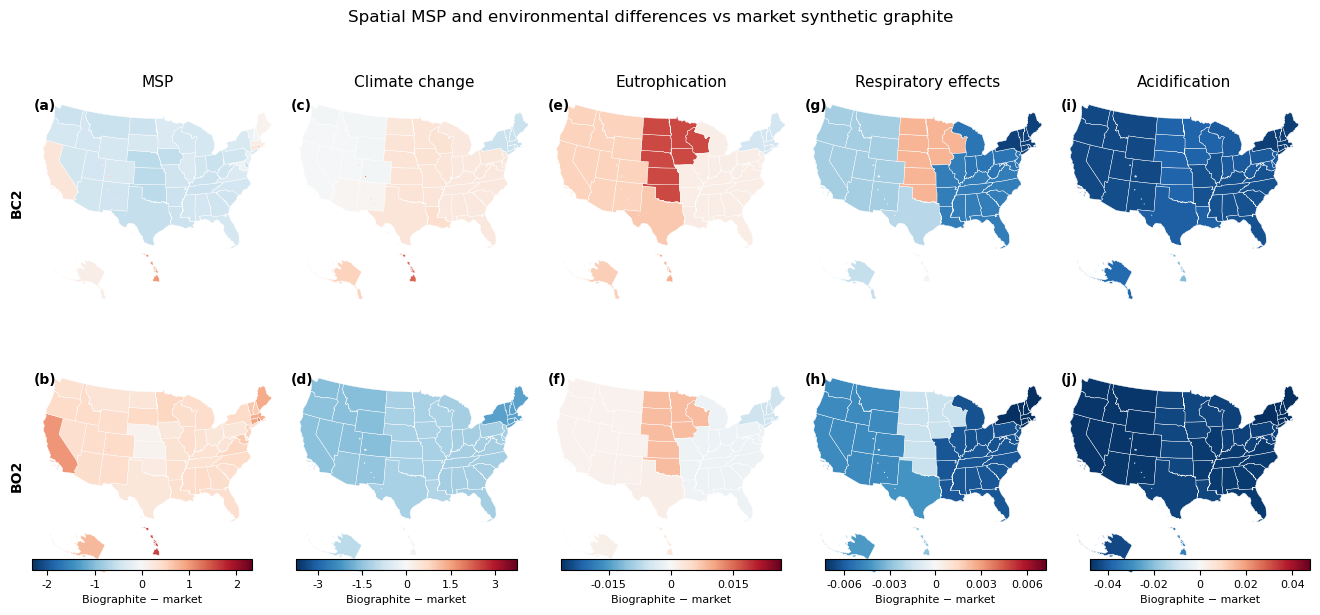

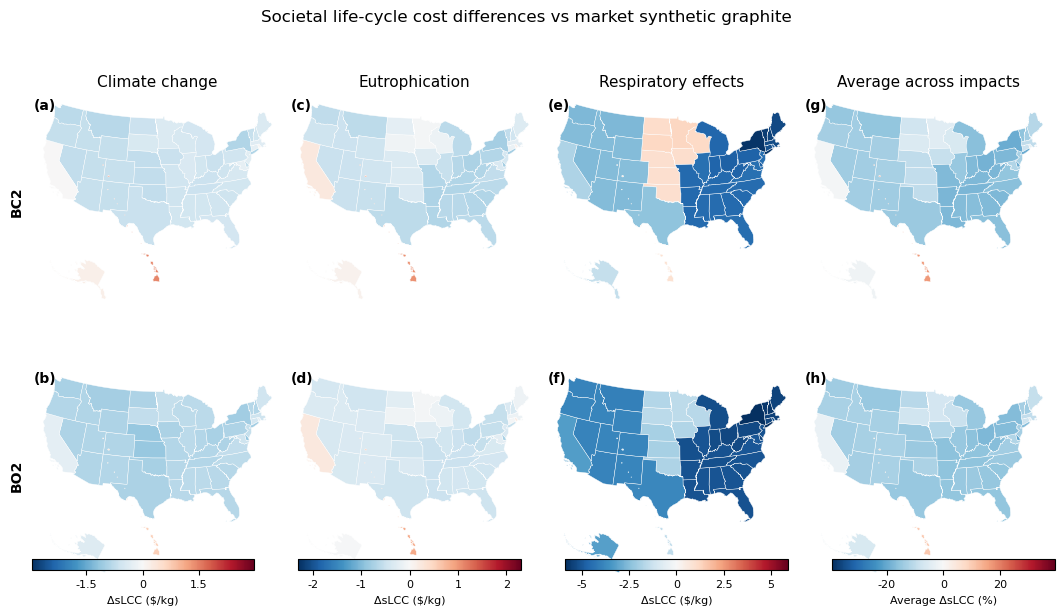

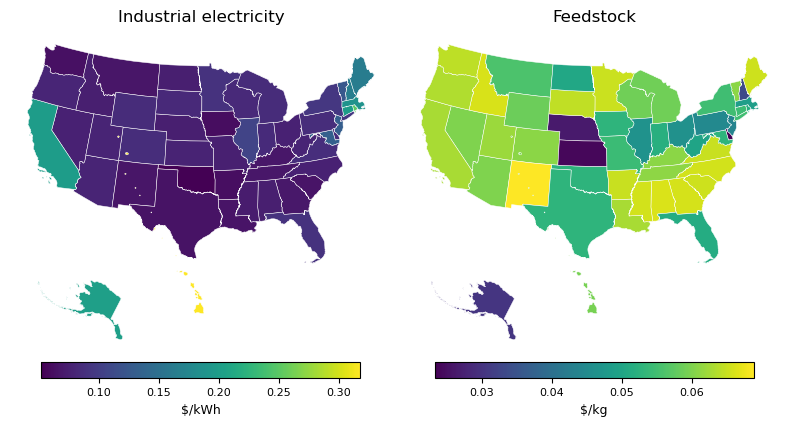

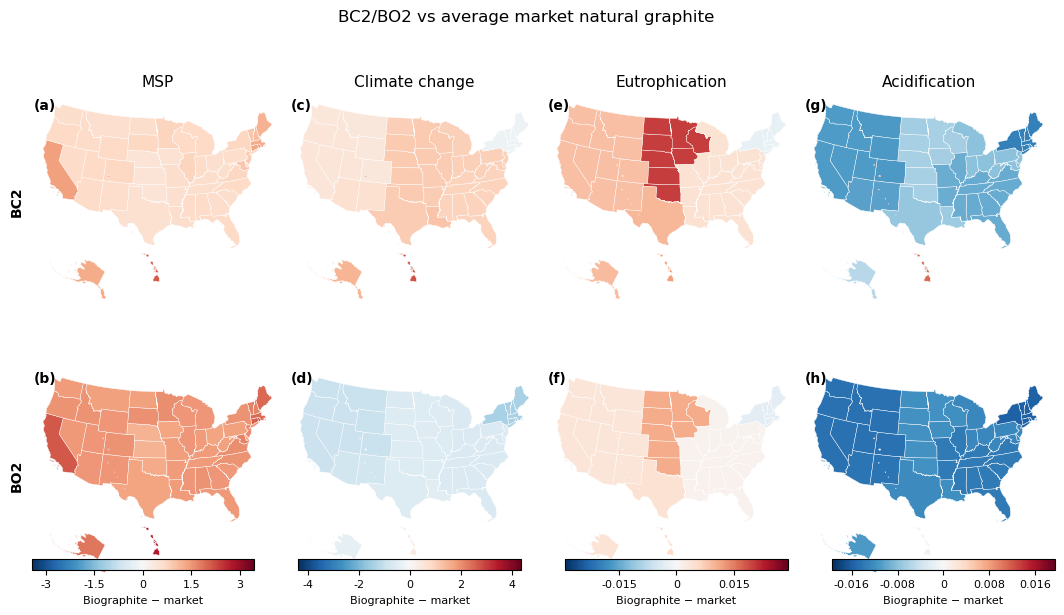

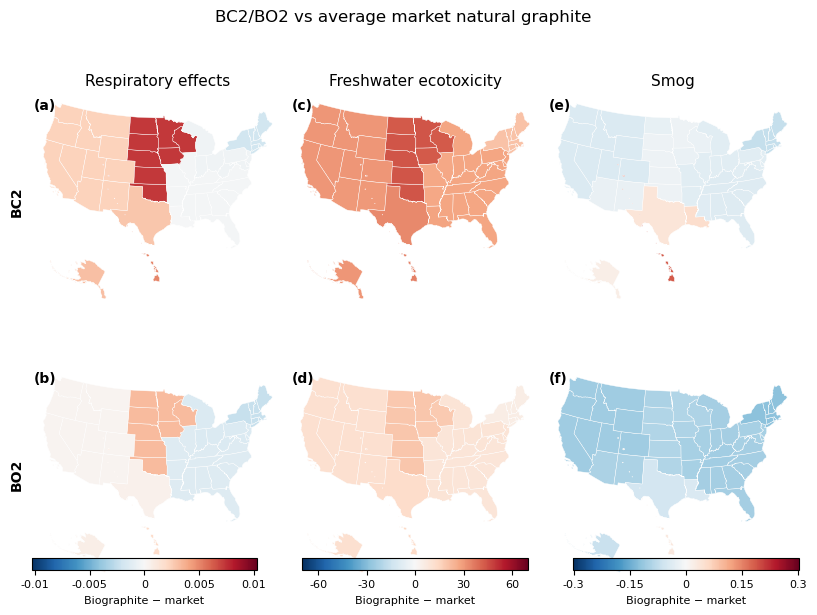

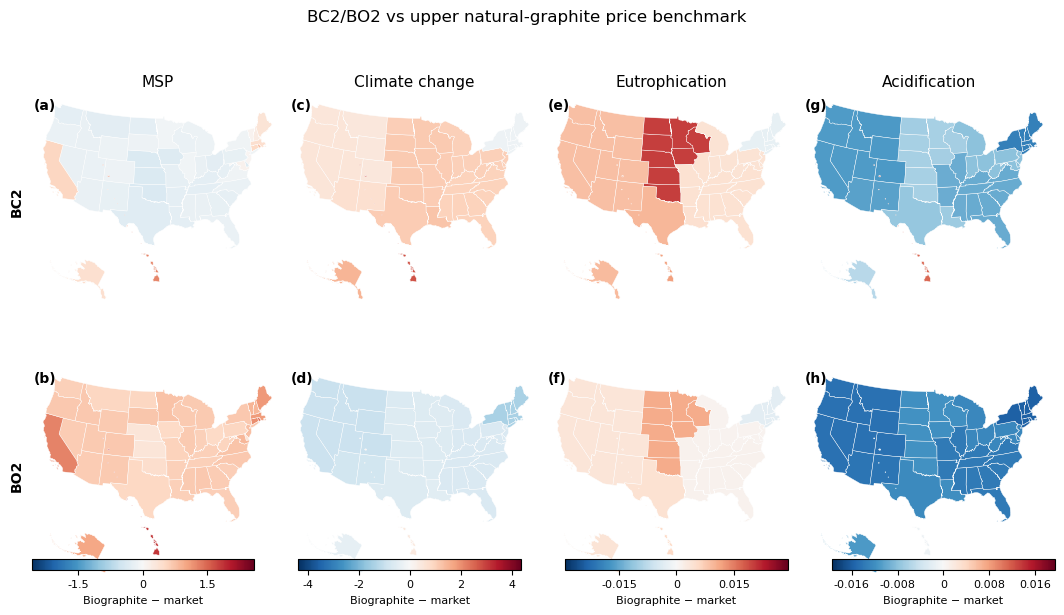

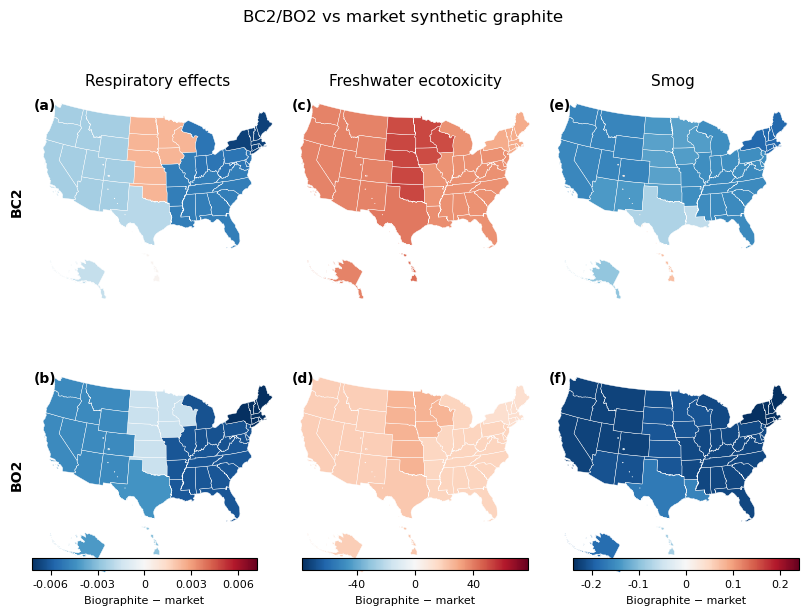

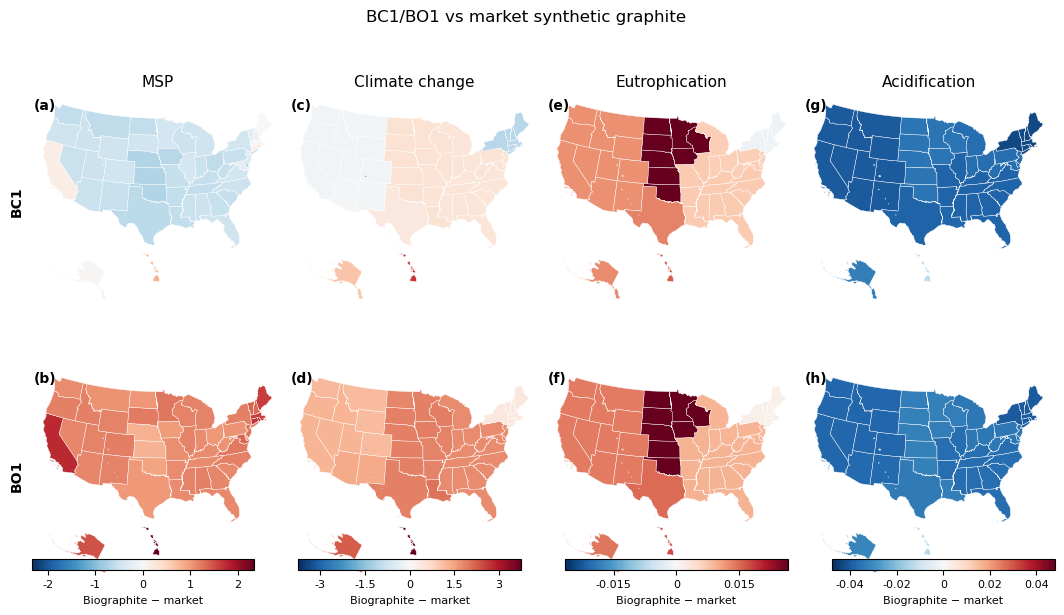

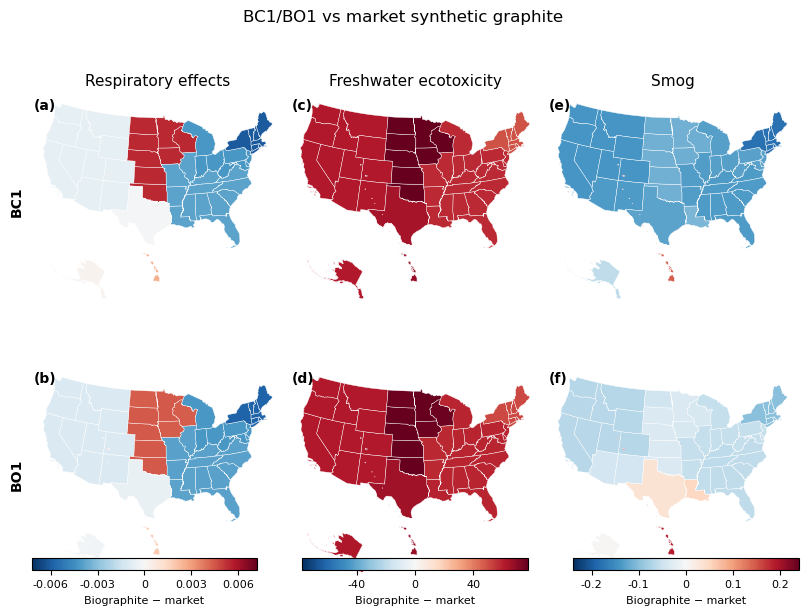

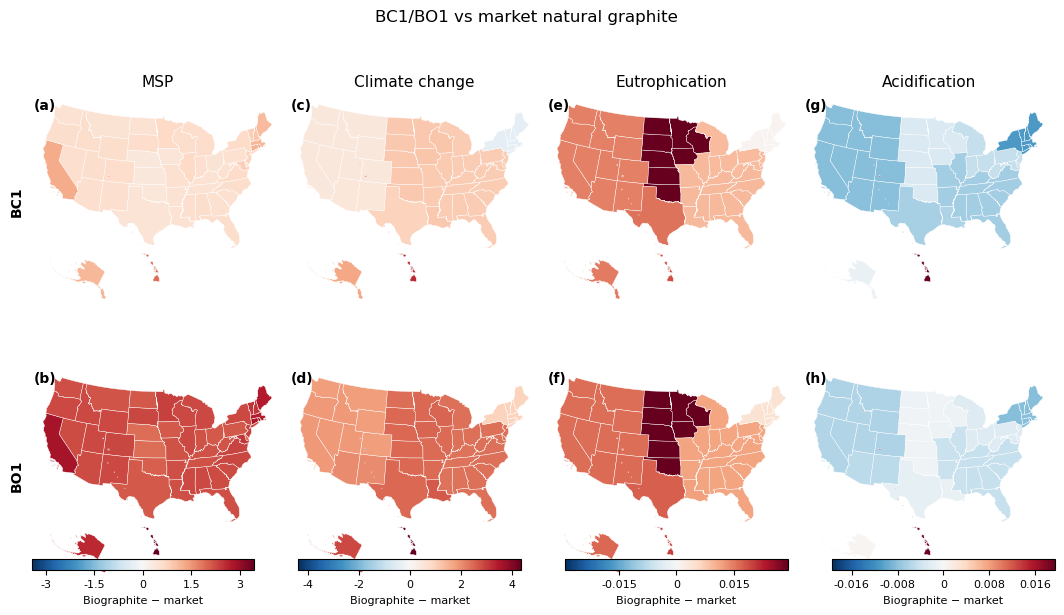

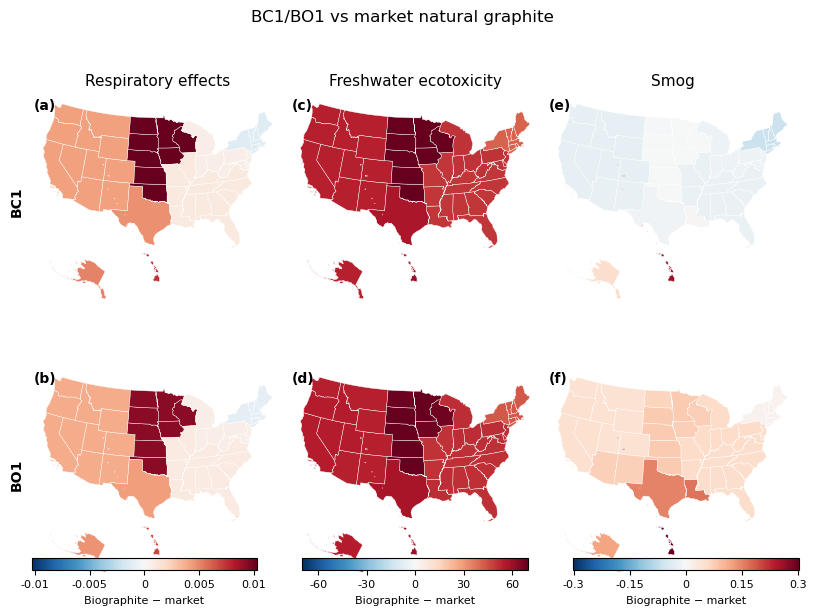

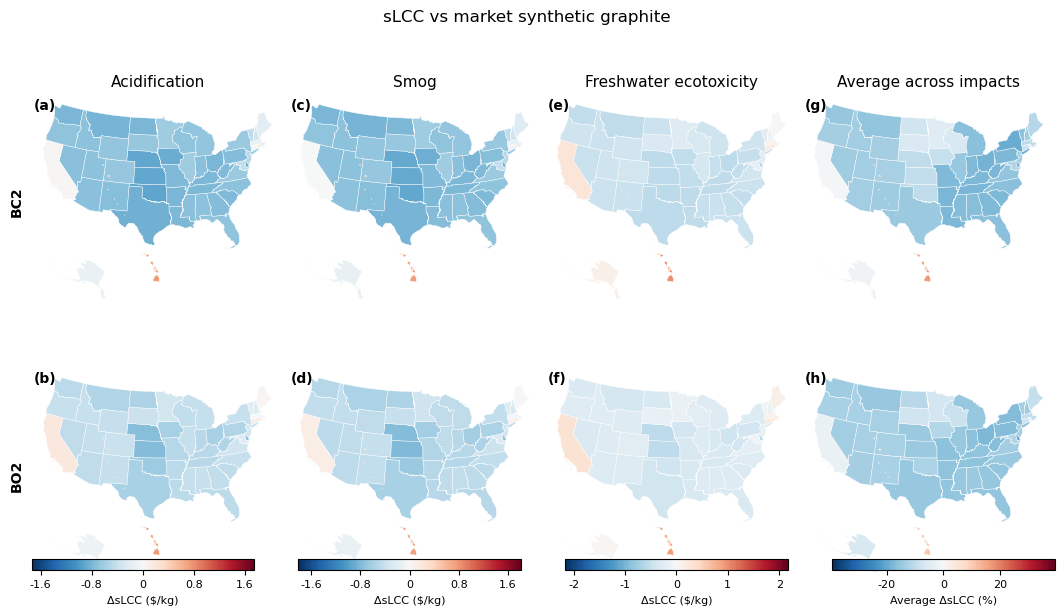

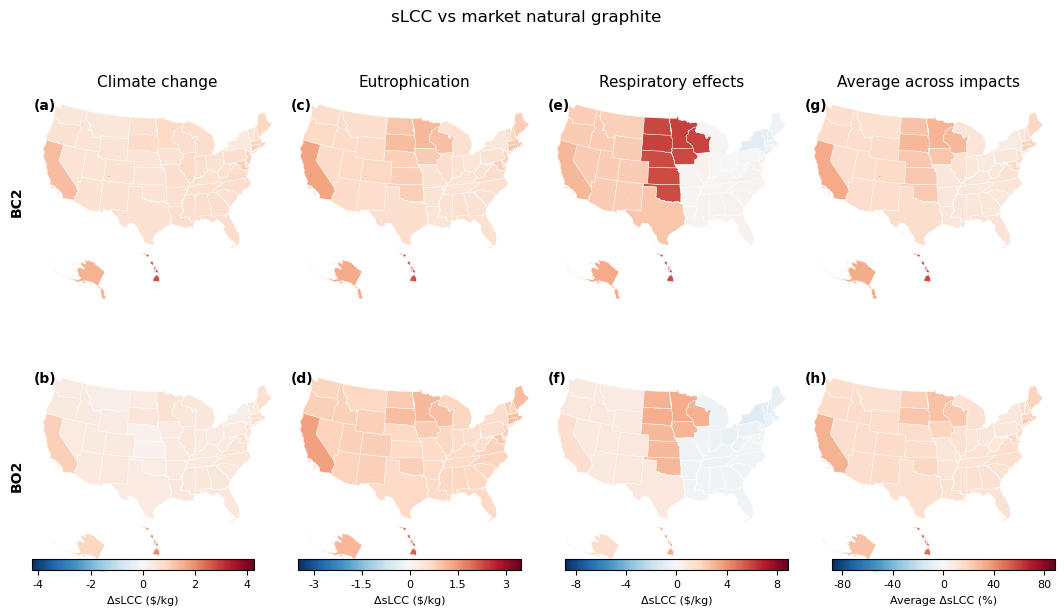

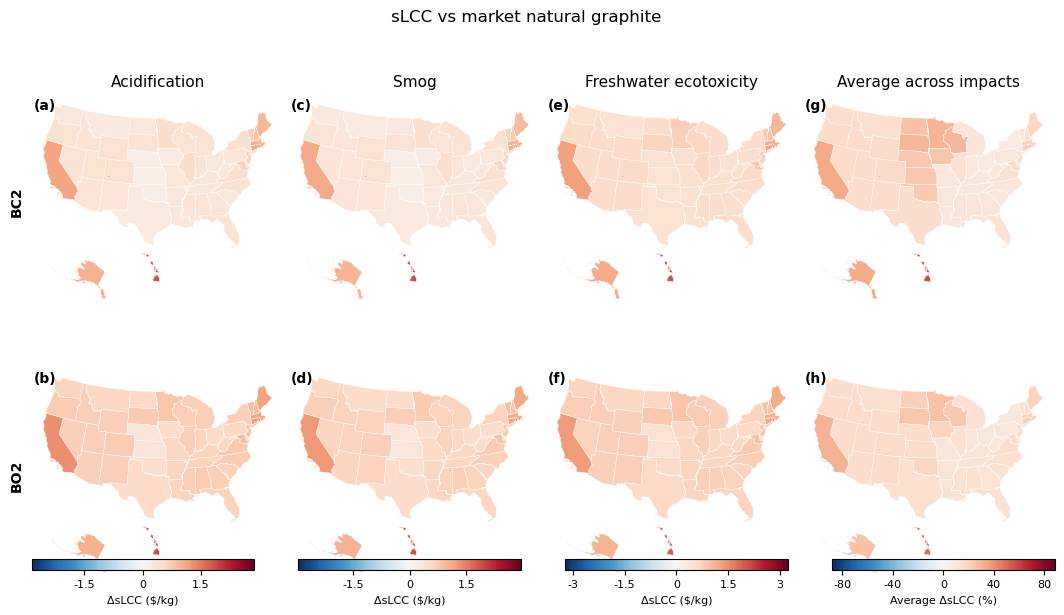

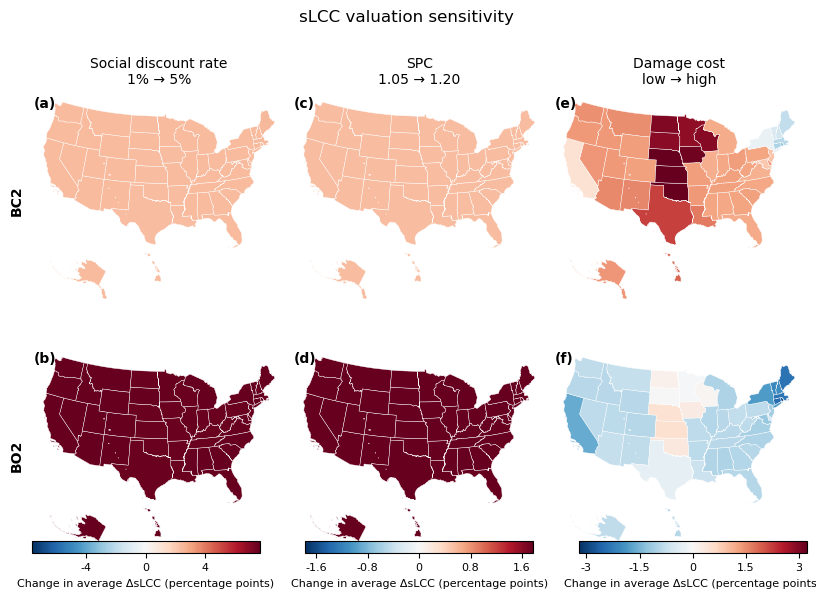

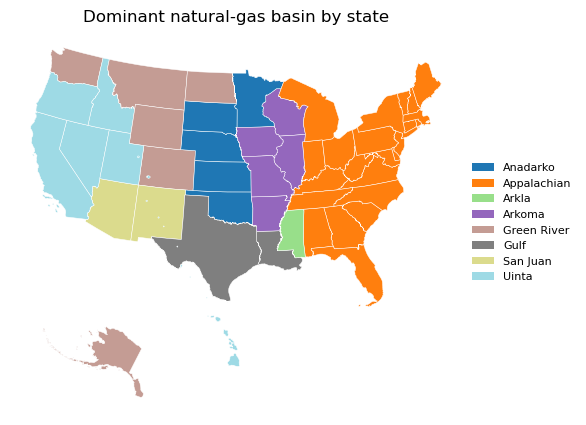

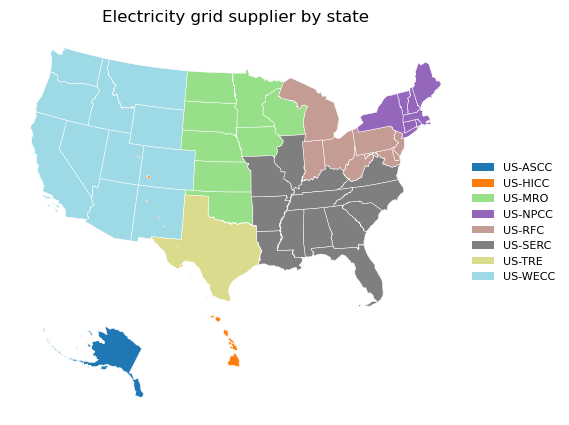

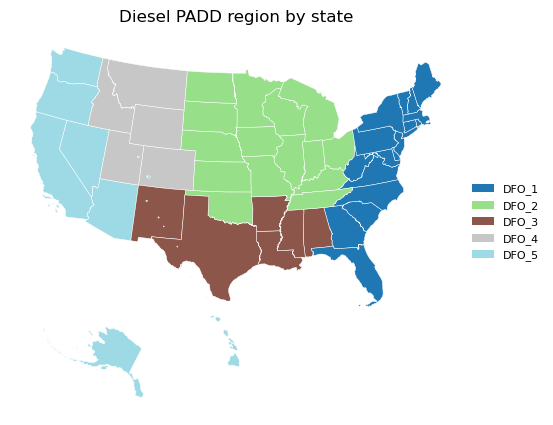

Generated 18 spatial map figures.


In [31]:
generated_maps = []
if RUN_FULL_SPATIAL and RUN_MAPS:
    from graphite_sus.plots.spatial_maps import load_us_states
    from graphite_sus.plots.spatial_lca_maps import make_figure5, make_lca_si_figure
    from graphite_sus.plots.spatial_slcc_maps import (
        make_figure6,
        make_slcc_si_figure,
        plot_slcc_sensitivity_figure,
    )
    from graphite_sus.plots.spatial_input_maps import (
        plot_state_input_prices,
        plot_source_assignment_maps,
    )

    states_geo = load_us_states(PATHS.state_geometries, compact=True)
    assert states_geo.state.nunique() == 51, 'Expected 50 states + DC in geometry layer'
    market_df = pd.read_csv(PATHS.market_impacts)

    def save_fig(fig, filename):
        path = OUTPUT_DIR / filename
        fig.savefig(path, dpi=300, bbox_inches='tight')
        generated_maps.append(filename)
        plt.show()
        plt.close(fig)

    # ---------------- Main text ----------------
    fig5, _ = make_figure5(
        states_geo, state_tea=state_tea, state_lca=state_lca, market_df=market_df
    )
    save_fig(fig5, 'figure5_spatial_lca_tea.png')

    fig6, _ = make_figure6(
        states_geo, slcc_synthetic=slcc_synthetic,
        impact_avg_synthetic=impact_avg_synthetic,
    )
    save_fig(fig6, 'figure6_spatial_slcc.png')

    # ---------------- SI Figure S16 ----------------
    fig, _ = plot_state_input_prices(states_geo, state_prices,title="")
    save_fig(fig, 'figureS16_state_input_prices.png')

    group1 = ('MSP','climate change','eutrophication','acidification')
    group2 = ('particulate matter formation','ecotoxicity: freshwater','photochemical oxidant formation')

    # S17-S20: BC2/BO2 market comparisons
    specs = [
        ('figureS17_BC2_BO2_vs_natural_mean.png', ('s_c2','s_o2'), 'natural', group1, 'mean', 'BC2/BO2 vs average market natural graphite'),
        ('figureS18_BC2_BO2_vs_natural_mean_other_impacts.png', ('s_c2','s_o2'), 'natural', group2, 'mean', 'BC2/BO2 vs average market natural graphite'),
        ('figureS19_BC2_BO2_vs_natural_upper.png', ('s_c2','s_o2'), 'natural', group1, 'high', 'BC2/BO2 vs upper natural-graphite price benchmark'),
        ('figureS20_BC2_BO2_vs_synthetic_other_impacts.png', ('s_c2','s_o2'), 'synthetic', group2, 'mean', 'BC2/BO2 vs market synthetic graphite'),
        ('figureS21_BC1_BO1_vs_synthetic.png', ('s_c1','s_o1'), 'synthetic', group1, 'mean', 'BC1/BO1 vs market synthetic graphite'),
        ('figureS22_BC1_BO1_vs_synthetic_other_impacts.png', ('s_c1','s_o1'), 'synthetic', group2, 'mean', 'BC1/BO1 vs market synthetic graphite'),
        ('figureS23_BC1_BO1_vs_natural.png', ('s_c1','s_o1'), 'natural', group1, 'mean', 'BC1/BO1 vs market natural graphite'),
        ('figureS24_BC1_BO1_vs_natural_other_impacts.png', ('s_c1','s_o1'), 'natural', group2, 'mean', 'BC1/BO1 vs market natural graphite'),
    ]
    for filename, scenarios_, market_kind_, metrics_, price_stat_, title_ in specs:
        fig, _ = make_lca_si_figure(
            states_geo,
            state_tea=state_tea,
            state_lca=state_lca,
            market_df=market_df,
            scenarios=scenarios_,
            market_kind=market_kind_,
            metrics=metrics_,
            price_stat=price_stat_,
            title=title_,
        )
        save_fig(fig, filename)

    # S25-S27: sLCC maps. The final column is the average of full-sLCC ratios
    # across the six impact categories, not the additive _ALL_ damage row.
    slcc_specs = [
        ('figureS25_slcc_vs_synthetic_other_impacts.png', slcc_synthetic, impact_avg_synthetic,
         ('acidification','photochemical oxidant formation','ecotoxicity: freshwater','_IMPACT_AVG_'),
         'sLCC vs market synthetic graphite'),
        ('figureS26_slcc_vs_natural_main_impacts.png', slcc_natural, impact_avg_natural,
         ('climate change','eutrophication','particulate matter formation','_IMPACT_AVG_'),
         'sLCC vs market natural graphite'),
        ('figureS27_slcc_vs_natural_other_impacts.png', slcc_natural, impact_avg_natural,
         ('acidification','photochemical oxidant formation','ecotoxicity: freshwater','_IMPACT_AVG_'),
         'sLCC vs market natural graphite'),
    ]
    for filename, slcc_df_, avg_df_, impacts_, title_ in slcc_specs:
        fig, _ = make_slcc_si_figure(
            states_geo, slcc_df=slcc_df_, impact_avg_df=avg_df_,
            scenarios=('s_c2','s_o2'), impacts=impacts_, title=title_
        )
        save_fig(fig, filename)

    # S29: state-wise 2^3 factorial main effects on the average ΔsLCC metric.
    if RUN_SLCC_SENSITIVITY and slcc_sensitivity_effects is not None:
        fig, _ = plot_slcc_sensitivity_figure(states_geo, slcc_sensitivity_effects)
        save_fig(fig, 'figureS29_slcc_valuation_sensitivity.png')

    # S30-S32: regional energy-source assignments.
    source_df = state_map.by_state.reset_index()
    source_maps = plot_source_assignment_maps(states_geo, source_df)
    source_names = {
        'ng_basin':'figureS30_natural_gas_basin.png',
        'ele_region':'figureS31_electricity_grid_supplier.png',
        'padd_region':'figureS32_diesel_padd_region.png',
    }
    for key, (fig, ax, mapped) in source_maps.items():
        save_fig(fig, source_names[key])

    print(f'Generated {len(generated_maps)} spatial map figures.')
else:
    print('Map generation skipped.')


### Query results for manuscript

In [32]:
# ============================================================
# Flexible spatial range query: MSP or LCIA
# ============================================================

REGION_DEF_PATH = (
    PROJECT_ROOT
    / "graphite_sus"
    / "data"
    / "spatial"
    / "study_region_definition.csv"
)

region_def = pd.read_csv(REGION_DEF_PATH)

PATHWAY_TO_SCENARIO = {
    "BC1": "s_c1",
    "BC2": "s_c2",
    "BO1": "s_o1",
    "BO2": "s_o2",
}
SCENARIO_TO_PATHWAY = {v: k for k, v in PATHWAY_TO_SCENARIO.items()}


# ------------------------------------------------------------
# Friendly aliases for metrics
# ------------------------------------------------------------
METRIC_ALIASES = {
    "msp": "MSP",
    "MSP": "MSP",

    "climate": "climate change",
    "climate change": "climate change",

    "acidification": "acidification",

    "eutrophication": "eutrophication",

    "freshwater ecotoxicity": "ecotoxicity: freshwater",
    "ecotoxicity": "ecotoxicity: freshwater",
    "ecotoxicity: freshwater": "ecotoxicity: freshwater",

    "pm": "particulate matter formation",
    "respiratory effects": "particulate matter formation",
    "particulate matter formation": "particulate matter formation",

    "smog": "photochemical oxidant formation",
    "smog formation": "photochemical oxidant formation",
    "photochemical oxidant formation": "photochemical oxidant formation",
}


# ------------------------------------------------------------
# Raw model units and optional manuscript-friendly display units
# ------------------------------------------------------------
METRIC_DISPLAY = {
    "MSP": {
        "factor": 1.0,
        "unit": "$/kg graphite",
    },
    "climate change": {
        "factor": 1.0,
        "unit": "kg CO2-eq/kg graphite",
    },
    "acidification": {
        "factor": 1000.0,
        "unit": "g SO2-eq/kg graphite",
    },
    "eutrophication": {
        "factor": 1000.0,
        "unit": "g N-eq/kg graphite",
    },
    "ecotoxicity: freshwater": {
        "factor": 1.0,
        "unit": "CTUe/kg graphite",
    },
    "particulate matter formation": {
        "factor": 1000.0,
        "unit": "g PM2.5-eq/kg graphite",
    },
    "photochemical oxidant formation": {
        "factor": 1.0,
        "unit": "kg O3-eq/kg graphite",
    },
}


def _as_list(x):
    if x is None:
        return None
    if isinstance(x, str):
        return [x]
    return list(x)


def _normalize_pathways(pathways):
    """Allow BC1/BC2/BO1/BO2 or s_c1/s_c2/s_o1/s_o2."""
    if pathways is None:
        return list(SCENARIOS)

    pathways = _as_list(pathways)

    out = []
    for p in pathways:
        p0 = str(p).strip()

        if p0.upper() in PATHWAY_TO_SCENARIO:
            out.append(PATHWAY_TO_SCENARIO[p0.upper()])
        elif p0 in SCENARIOS:
            out.append(p0)
        else:
            raise ValueError(
                f"Unknown pathway {p!r}. "
                f"Use {list(PATHWAY_TO_SCENARIO)} or {list(SCENARIOS)}."
            )

    return out


def _normalize_metric(metric):
    key = str(metric).strip()

    if key in METRIC_ALIASES:
        return METRIC_ALIASES[key]

    key_lower = key.lower()
    if key_lower in METRIC_ALIASES:
        return METRIC_ALIASES[key_lower]

    raise ValueError(
        f"Unknown metric {metric!r}.\n"
        f"Available: MSP + {list(CANON_IMPACTS)}"
    )


def spatial_range(
    metric,
    *,
    pathways=None,
    include_regions=None,
    exclude_regions=None,
    include_states=None,
    exclude_states=None,
    basis="states",
    manuscript_units=True,
    show_selected=False,
):
    """
    Obtain spatial min/max/range for MSP or an LCIA impact.

    Parameters
    ----------
    metric :
        "MSP", "climate change", "acidification",
        "eutrophication", "ecotoxicity: freshwater",
        "particulate matter formation",
        "photochemical oxidant formation"

        Friendly aliases such as "climate", "PM", "smog",
        "freshwater ecotoxicity" also work.

    pathways :
        e.g. "BC2"
        or ["BC2", "BO2"]
        or ["s_c2", "s_o2"]
        None = all four pathways.

    include_regions :
        Keep only these regions.
        Example: ["Eastern", "Western+Texas"]

    exclude_regions :
        Remove these regions.
        Example: ["Pacific", "Northeast coastal"]

    include_states :
        Optional explicit state filter.
        Example: ["TX", "OK", "KS"]

    exclude_states :
        Optional states to remove.
        Example: ["HI", "AK"]

    basis :
        "states"
            Range across all selected STATE values.
            This is normally what you want when saying
            "values across these regions ranged from X to Y."

        "region_means"
            First average states within each region,
            then report range among those regional means.

    manuscript_units :
        True converts kg -> g for acidification,
        eutrophication and PM to match manuscript figures.

    show_selected :
        If True, also display all selected underlying values.
    """

    metric = _normalize_metric(metric)
    scenarios = _normalize_pathways(pathways)

    include_regions = _as_list(include_regions)
    exclude_regions = _as_list(exclude_regions)
    include_states = _as_list(include_states)
    exclude_states = _as_list(exclude_states)

    # --------------------------------------------------------
    # Select source table
    # --------------------------------------------------------
    if metric == "MSP":
        if state_tea is None:
            raise RuntimeError("state_tea has not been generated.")

        d = state_tea[
            ["state", "scenario", "MSP"]
        ].copy()

        value_col = "MSP"

    else:
        if state_lca is None:
            raise RuntimeError("state_lca has not been generated.")

        if metric not in state_lca.columns:
            raise KeyError(
                f"{metric!r} not found in state_lca. "
                f"Available impacts: {list(CANON_IMPACTS)}"
            )

        d = state_lca[
            ["state", "scenario", metric]
        ].copy()

        value_col = metric

    # --------------------------------------------------------
    # Add study-region definition
    # --------------------------------------------------------
    d = d.merge(
        region_def[["state", "region", "region_order"]],
        on="state",
        how="left",
        validate="many_to_one",
    )

    if d["region"].isna().any():
        missing = sorted(d.loc[d["region"].isna(), "state"].unique())
        raise ValueError(f"States missing study-region assignment: {missing}")

    # --------------------------------------------------------
    # Pathway filtering
    # --------------------------------------------------------
    d = d[d["scenario"].isin(scenarios)].copy()

    # --------------------------------------------------------
    # Geographic filtering
    #
    # If include_regions is given:
    #   start with their UNION.
    #
    # Then exclusions are applied.
    # --------------------------------------------------------
    if include_regions is not None:
        bad = sorted(set(include_regions) - set(region_def["region"]))
        if bad:
            raise ValueError(f"Unknown include_regions: {bad}")

        d = d[d["region"].isin(include_regions)].copy()

    if exclude_regions is not None:
        bad = sorted(set(exclude_regions) - set(region_def["region"]))
        if bad:
            raise ValueError(f"Unknown exclude_regions: {bad}")

        d = d[~d["region"].isin(exclude_regions)].copy()

    if include_states is not None:
        include_states = [s.upper() for s in include_states]
        d = d[d["state"].isin(include_states)].copy()

    if exclude_states is not None:
        exclude_states = [s.upper() for s in exclude_states]
        d = d[~d["state"].isin(exclude_states)].copy()

    if d.empty:
        raise ValueError("No states remain after applying the filters.")

    # --------------------------------------------------------
    # Convert to manuscript-friendly units
    # --------------------------------------------------------
    if manuscript_units:
        factor = METRIC_DISPLAY[metric]["factor"]
        unit = METRIC_DISPLAY[metric]["unit"]
    else:
        factor = 1.0

        raw_units = {
            "MSP": "$/kg graphite",
            "climate change": "kg CO2-eq/kg graphite",
            "acidification": "kg SO2-eq/kg graphite",
            "eutrophication": "kg N-eq/kg graphite",
            "ecotoxicity: freshwater": "CTUe/kg graphite",
            "particulate matter formation": "kg PM2.5-eq/kg graphite",
            "photochemical oxidant formation": "kg O3-eq/kg graphite",
        }
        unit = raw_units[metric]

    d["value"] = d[value_col].astype(float) * factor
    d["pathway"] = d["scenario"].map(SCENARIO_TO_PATHWAY)

    # --------------------------------------------------------
    # A. Range across individual states
    # --------------------------------------------------------
    if basis == "states":

        rows = []

        for sc, g in d.groupby("scenario", sort=False):
            g = g.copy()

            imin = g["value"].idxmin()
            imax = g["value"].idxmax()

            rows.append({
                "scenario": sc,
                "pathway": SCENARIO_TO_PATHWAY[sc],
                "metric": metric,
                "unit": unit,

                "n_states": g["state"].nunique(),
                "regions": ", ".join(
                    region_def[
                        region_def["region"].isin(g["region"].unique())
                    ]
                    .sort_values("region_order")["region"]
                    .drop_duplicates()
                    .tolist()
                ),

                "min": float(g.loc[imin, "value"]),
                "min_state": g.loc[imin, "state"],
                "min_region": g.loc[imin, "region"],

                "max": float(g.loc[imax, "value"]),
                "max_state": g.loc[imax, "state"],
                "max_region": g.loc[imax, "region"],

                "range_width": float(
                    g.loc[imax, "value"] - g.loc[imin, "value"]
                ),

                "mean": float(g["value"].mean()),
                "median": float(g["value"].median()),
            })

        summary = pd.DataFrame(rows)

    # --------------------------------------------------------
    # B. Range across REGION MEANS
    # --------------------------------------------------------
    elif basis == "region_means":

        region_values = (
            d.groupby(
                ["scenario", "pathway", "region", "region_order"],
                as_index=False,
                observed=True,
            )
            .agg(
                value=("value", "mean"),
                n_states=("state", "nunique"),
            )
        )

        rows = []

        for sc, g in region_values.groupby("scenario", sort=False):
            imin = g["value"].idxmin()
            imax = g["value"].idxmax()

            rows.append({
                "scenario": sc,
                "pathway": SCENARIO_TO_PATHWAY[sc],
                "metric": metric,
                "unit": unit,

                "n_regions": g["region"].nunique(),

                "min": float(g.loc[imin, "value"]),
                "min_region": g.loc[imin, "region"],

                "max": float(g.loc[imax, "value"]),
                "max_region": g.loc[imax, "region"],

                "range_width": float(
                    g.loc[imax, "value"] - g.loc[imin, "value"]
                ),

                "mean_of_region_means": float(g["value"].mean()),
                "median_of_region_means": float(g["value"].median()),
            })

        summary = pd.DataFrame(rows)

        if show_selected:
            display(
                region_values.sort_values(
                    ["scenario", "region_order"]
                ).drop(columns="region_order")
            )

    else:
        raise ValueError(
            "basis must be either 'states' or 'region_means'."
        )

    # Nice display order
    summary["__order"] = summary["scenario"].map(
        {sc: i for i, sc in enumerate(SCENARIOS)}
    )

    summary = (
        summary
        .sort_values("__order")
        .drop(columns="__order")
        .reset_index(drop=True)
    )

    display(summary.round(4))

    if show_selected and basis == "states":
        display(
            d[
                ["state", "region", "pathway", "value"]
            ]
            .sort_values(["pathway", "region", "value"])
            .reset_index(drop=True)
        )

    return summary, d

In [33]:
print("Available impacts:")
for x in CANON_IMPACTS:
    print(" -", x)

Available impacts:
 - climate change
 - acidification
 - eutrophication
 - ecotoxicity: freshwater
 - particulate matter formation
 - photochemical oxidant formation


In [34]:
spatial_range(
    "MSP",
    pathways=["BC2", "BO2"],
)

,scenario,pathway,metric,unit,n_states,regions,min,min_state,min_region,max,max_state,max_region,range_width,mean,median
0,s_c2,BC2,MSP,$/kg graphite,51,"Pacific, Western+Texas, Central, Upper, Easter...",4.1152,OK,Central,5.7653,HI,Pacific,1.6501,4.4290,4.3165
1,s_o2,BO2,MSP,$/kg graphite,51,"Pacific, Western+Texas, Central, Upper, Easter...",4.8322,KS,Central,6.3343,HI,Pacific,1.5020,5.2279,5.1757


(  scenario pathway metric           unit  n_states  \
 0     s_c2     BC2    MSP  $/kg graphite        51   
 1     s_o2     BO2    MSP  $/kg graphite        51   
 
                                              regions       min min_state  \
 0  Pacific, Western+Texas, Central, Upper, Easter...  4.115199        OK   
 1  Pacific, Western+Texas, Central, Upper, Easter...  4.832228        KS   
 
   min_region       max max_state max_region  range_width      mean    median  
 0    Central  5.765265        HI    Pacific     1.650066  4.429029  4.316505  
 1    Central  6.334275        HI    Pacific     1.502046  5.227914  5.175658  ,
     state scenario       MSP         region  region_order     value pathway
 1      AK     s_c2  4.912525        Pacific             1  4.912525     BC2
 3      AK     s_o2  5.501415        Pacific             1  5.501415     BO2
 5      AL     s_c2  4.316281        Eastern             5  4.316281     BC2
 7      AL     s_o2  5.189855        Eastern       

In [35]:
spatial_range(
    "MSP",
    pathways=["BC2", "BO2"],
    exclude_regions=["Pacific", "Northeast coastal","Central"], # other regions: Eastern, Central, Western+Texas
    basis="states", # or "region_means"
)

,scenario,pathway,metric,unit,n_states,regions,min,min_state,min_region,max,max_state,max_region,range_width,mean,median
0,s_c2,BC2,MSP,$/kg graphite,39,"Western+Texas, Upper, Eastern",4.1683,DE,Eastern,4.6105,DC,Eastern,0.4421,4.3175,4.3042
1,s_o2,BO2,MSP,$/kg graphite,39,"Western+Texas, Upper, Eastern",4.8633,DE,Eastern,5.3645,DC,Eastern,0.5012,5.1485,5.1601


(  scenario pathway metric           unit  n_states  \
 0     s_c2     BC2    MSP  $/kg graphite        39   
 1     s_o2     BO2    MSP  $/kg graphite        39   
 
                          regions       min min_state min_region       max  \
 0  Western+Texas, Upper, Eastern  4.168326        DE    Eastern  4.610456   
 1  Western+Texas, Upper, Eastern  4.863279        DE    Eastern  5.364508   
 
   max_state max_region  range_width      mean    median  
 0        DC    Eastern     0.442130  4.317497  4.304192  
 1        DC    Eastern     0.501229  5.148508  5.160081  ,
     state scenario       MSP         region  region_order     value pathway
 5      AL     s_c2  4.316281        Eastern             5  4.316281     BC2
 7      AL     s_o2  5.189855        Eastern             5  5.189855     BO2
 9      AR     s_c2  4.239619        Eastern             5  4.239619     BC2
 11     AR     s_o2  5.121821        Eastern             5  5.121821     BO2
 13     AZ     s_c2  4.309835  Wes

## 12. Acceptance gate and run manifest

In [36]:
checks = {
    'state_price_coverage': state_prices.state.nunique() >= 48,
    'tea_reconciliation': bool(recon_df['pass'].all()),
    'damage_categories_complete': set(CANON_IMPACTS).issubset(damage_schedules),
    'damage_schedule_length_30': all(len(damage_schedules[c]['central']) == 30 for c in CANON_IMPACTS),
}
if RUN_FULL_SPATIAL:
    checks.update({
        'regional_source_and_EF_inputs': bool(regional_ok),
        'state_TEA_complete': state_tea is not None and not state_tea.MSP.isna().any(),
        'state_LCA_complete': state_lca is not None and not state_lca[list(CANON_IMPACTS)].isna().any().any(),
        'mass_allocation_audited': allocation_audit is not None and bool(allocation_audit['pass'].all()),
        'netl_fuel_reference_applied': (not fuel_ef_audit.empty) and bool(fuel_ef_audit['passed'].all()),
        'spatial_fuel_ranges_match_reference': bool(fuel_spatial_range_audit['passed'].all()),
        'electricity_lcia_provenance_exact': bool(electricity_ef_audit['passed'].all()),
        'electricity_uncertainty_matches_regional_envelope': bool(electricity_uncertainty_audit['passed'].all()),
        'synthetic_sLCC_complete': slcc_synthetic is not None and slcc_synthetic.impact_category.notna().all(),
        'natural_sLCC_complete': slcc_natural is not None and slcc_natural.impact_category.notna().all(),
        'impact_average_metric_complete': impact_avg_synthetic is not None and impact_avg_synthetic.state.nunique() == state_lca.state.nunique(),
    })
    if lca_regression is not None:
        if legacy_reference_current:
            checks['readonly_LCA_matches_current_legacy'] = bool(
                (lca_regression.max_abs_delta < 1e-8).all()
            )
        else:
            # Historical pre-update reference is informative only; current
            # electricity/fuel provenance audits above remain hard gates.
            checks['historical_legacy_reference_not_used_as_gate'] = True
    if RUN_SLCC_SENSITIVITY:
        checks['sLCC_factorial_all_states'] = sensitivity_coverage is not None and bool(sensitivity_coverage['pass'].all())
        checks['sLCC_factorial_effects_complete'] = (
            slcc_sensitivity_effects is not None
            and slcc_sensitivity_effects.state.nunique() == state_lca.state.nunique()
            and set(slcc_sensitivity_effects.factor) == {'social_rate','spc','damage_scenario'}
        )
    if RUN_MAPS:
        required_map_files = {
            'figure5_spatial_lca_tea.png','figure6_spatial_slcc.png','figureS16_state_input_prices.png',
            'figureS17_BC2_BO2_vs_natural_mean.png','figureS18_BC2_BO2_vs_natural_mean_other_impacts.png',
            'figureS19_BC2_BO2_vs_natural_upper.png','figureS20_BC2_BO2_vs_synthetic_other_impacts.png',
            'figureS21_BC1_BO1_vs_synthetic.png','figureS22_BC1_BO1_vs_synthetic_other_impacts.png',
            'figureS23_BC1_BO1_vs_natural.png','figureS24_BC1_BO1_vs_natural_other_impacts.png',
            'figureS25_slcc_vs_synthetic_other_impacts.png','figureS26_slcc_vs_natural_main_impacts.png',
            'figureS27_slcc_vs_natural_other_impacts.png','figureS30_natural_gas_basin.png',
            'figureS31_electricity_grid_supplier.png','figureS32_diesel_padd_region.png',
        }
        if RUN_SLCC_SENSITIVITY:
            required_map_files.add('figureS29_slcc_valuation_sensitivity.png')
        checks['required_spatial_maps_generated'] = all((OUTPUT_DIR/f).exists() for f in required_map_files)

check_df = pd.DataFrame([{'check':k,'pass':bool(v)} for k,v in checks.items()])
display(check_df)
assert check_df['pass'].all()

manifest = {
    'project': PROJECT_NAME,
    'tea_profile': TEA_PROFILE,
    'electricity_price_mode': ELECTRICITY_PRICE_MODE,
    'electricity_snapshot': ELECTRICITY_SNAPSHOT,
    'social_rate': SOCIAL_RATE,
    'spc': SPC,
    'damage_scenario': DAMAGE_SCENARIO,
    'allocation_scheme': 'mass',
    'spatial_lca_mode': 'read_only_formula_evaluation',
    'spatial_lca_fingerprint': current_spatial_lca_fingerprint if RUN_FULL_SPATIAL else None,
    'historical_legacy_reference_status': legacy_reference_status if RUN_FULL_SPATIAL else None,
    'historical_legacy_reference_exact_gate': bool(legacy_reference_current) if RUN_FULL_SPATIAL else False,
    'fuel_ef_reference': fuel_reference_manifest(),
    'electricity_ef_table': str(PATHS.electricity_ef),
    'electricity_ef_metadata': json.loads(
        PATHS.electricity_ef.with_suffix(PATHS.electricity_ef.suffix + '.meta.json').read_text()
    ) if PATHS.electricity_ef.with_suffix(PATHS.electricity_ef.suffix + '.meta.json').exists() else None,
    'slcc_sensitivity_design': '2^3 full factorial; state-wise main effects on impact-average full-sLCC ratio',
    'run_full_spatial': RUN_FULL_SPATIAL,
    'run_slcc_sensitivity': RUN_SLCC_SENSITIVITY,
    'run_maps': RUN_MAPS,
    'checks': {r['check']: bool(r['pass']) for r in check_df.to_dict('records')},
}
(OUTPUT_DIR/'run_manifest.json').write_text(json.dumps(manifest,indent=2))
print('SPATIAL WORKFLOW ACCEPTED' if RUN_FULL_SPATIAL else 'SPATIAL PREFLIGHT ACCEPTED')


,check,pass
0,state_price_coverage,True
1,tea_reconciliation,True
2,damage_categories_complete,True
3,damage_schedule_length_30,True
4,regional_source_and_EF_inputs,True
5,state_TEA_complete,True
6,state_LCA_complete,True
7,mass_allocation_audited,True
8,netl_fuel_reference_applied,True
9,spatial_fuel_ranges_match_reference,True


SPATIAL WORKFLOW ACCEPTED
